# 04 — ARIMA Forecasting

This version is designed to prevent the `ValueError: Input contains NaN` problem by validating the ARIMA forecast before calculating metrics. It tries the original ARIMA(5,1,2) first and automatically falls back to simpler ARIMA orders if the original model produces invalid forecasts.


In [4]:
from pathlib import Path

In [6]:
# ==========================================
# 04 ARIMA - LOAD DATA
# ==========================================

import pandas as pd
import numpy as np
from pathlib import Path

# Find processed dataset
candidates = [
    Path("data/processed_data.csv"),
    Path("UAC_Forecasting_Project/data/processed_data.csv"),
]

data_path = next(
    (path for path in candidates if path.exists()),
    None
)

if data_path is None:
    raise FileNotFoundError(
        "processed_data.csv not found.\n\n"
        "Checked:\n"
        + "\n".join(str(path) for path in candidates)
        + f"\n\nCurrent working directory:\n{Path.cwd()}"
    )

# Load dataset
df = pd.read_csv(data_path)

print("✅ Dataset loaded successfully")
print("📁 File:", data_path)
print("📊 Shape:", df.shape)

# Clean Date
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Clean target
target = "Children in HHS Care"

df[target] = (
    df[target]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.replace("$", "", regex=False)
    .str.strip()
)

df[target] = pd.to_numeric(
    df[target],
    errors="coerce"
)

# Remove invalid rows
df = df.dropna(
    subset=["Date", target]
)

df = df.replace(
    [np.inf, -np.inf],
    np.nan
)

df = df.dropna(
    subset=[target]
)

# Sort chronologically
df = df.sort_values("Date")

# If duplicate dates exist, aggregate them
df = (
    df.groupby("Date")[target]
    .mean()
    .to_frame()
)

# Final time series
series = df[target].astype(float)

print("\n✅ Data preparation complete")
print("Observations:", len(series))
print("Start date:", series.index.min())
print("End date:", series.index.max())

display(series.head())

✅ Dataset loaded successfully
📁 File: UAC_Forecasting_Project\data\processed_data.csv
📊 Shape: (1170, 14)

✅ Data preparation complete
Observations: 720
Start date: 2023-01-12 00:00:00
End date: 2025-12-21 00:00:00


Date
2023-01-12    6566.0
2023-01-22    7122.0
2023-01-23    7280.0
2023-01-24    7433.0
2023-01-25    7538.0
Name: Children in HHS Care, dtype: float64

In [7]:
# 2. Train/test split

if len(series) < 12:
    raise ValueError(
        f"Only {len(series)} usable observations are available. "
        "At least 12 observations are recommended for this ARIMA experiment."
    )

split_index = int(len(series) * 0.80)

# Protect against an empty test set
split_index = max(1, min(split_index, len(series) - 1))

train = series.iloc[:split_index].copy()
test = series.iloc[split_index:].copy()

print("Training observations:", len(train))
print("Testing observations :", len(test))
print("Training period:", train.index.min(), "to", train.index.max())
print("Testing period :", test.index.min(), "to", test.index.max())


Training observations: 576
Testing observations : 144
Training period: 2023-01-12 00:00:00 to 2025-05-13 00:00:00
Testing period : 2025-05-14 00:00:00 to 2025-12-21 00:00:00


In [9]:
# ==========================================
# DIAGNOSE THE ARIMA INPUT
# ==========================================

print("TRAINING DATA")
print("=" * 50)

print("Length:", len(train))
print("NaN:", train.isna().sum())
print("Infinite:", np.isinf(train).sum())
print("Unique values:", train.nunique())

print("\nFirst values:")
print(train.head(10))

print("\nLast values:")
print(train.tail(10))

print("\nStatistics:")
print(train.describe())

print("\nDate frequency:")
print(train.index.to_series().diff().value_counts().head(10))

print("\nData type:")
print(train.dtype)

TRAINING DATA
Length: 576
NaN: 0
Infinite: 0
Unique values: 533

First values:
Date
2023-01-12    6566.0
2023-01-22    7122.0
2023-01-23    7280.0
2023-01-24    7433.0
2023-01-25    7538.0
2023-01-29    7472.0
2023-01-30    7743.0
2023-01-31    7803.0
2023-02-01    7903.0
2023-02-02    7879.0
Name: Children in HHS Care, dtype: float64

Last values:
Date
2025-04-30    2309.0
2025-05-01    2306.0
2025-05-04    2335.0
2025-05-05    2331.0
2025-05-06    2339.0
2025-05-07    2335.0
2025-05-08    2361.0
2025-05-11    2385.0
2025-05-12    2392.0
2025-05-13    2394.0
Name: Children in HHS Care, dtype: float64

Statistics:
count      576.000000
mean      7014.081597
std       2341.262486
min       2109.000000
25%       6001.250000
50%       7329.000000
75%       8349.000000
max      11516.000000
Name: Children in HHS Care, dtype: float64

Date frequency:
Date
1 days     450
3 days      96
4 days      19
2 days       6
5 days       2
10 days      1
6 days       1
Name: count, dtype: int64

Data 

In [10]:
# 4. Create the forecast series

forecast = pd.Series(
    forecast_values,
    index=test.index,
    name="ARIMA Forecast"
)

print("Forecast observations:", len(forecast))
print("Forecast NaN values:", forecast.isna().sum())
print("Forecast infinite values:", np.isinf(forecast).sum())

display(forecast.head())


Forecast observations: 144
Forecast NaN values: 144
Forecast infinite values: 0


Date
2025-05-14   NaN
2025-05-15   NaN
2025-05-18   NaN
2025-05-19   NaN
2025-05-21   NaN
Name: ARIMA Forecast, dtype: float64

Training observations: 576
Testing observations: 144

Fitting ARIMA(1,1,1)...
✅ ARIMA model fitted successfully.

Forecast:
Date
2025-05-14    2394.254849
2025-05-15    2394.258821
2025-05-18    2394.258883
2025-05-19    2394.258884
2025-05-21    2394.258884
dtype: float64

Forecast NaN: 0
Forecast infinite: 0

Valid evaluation rows: 144

ARIMA MODEL RESULTS
Model : ARIMA(1,1,1)
MAE   : 186.62
RMSE  : 227.39
MAPE  : 8.77%


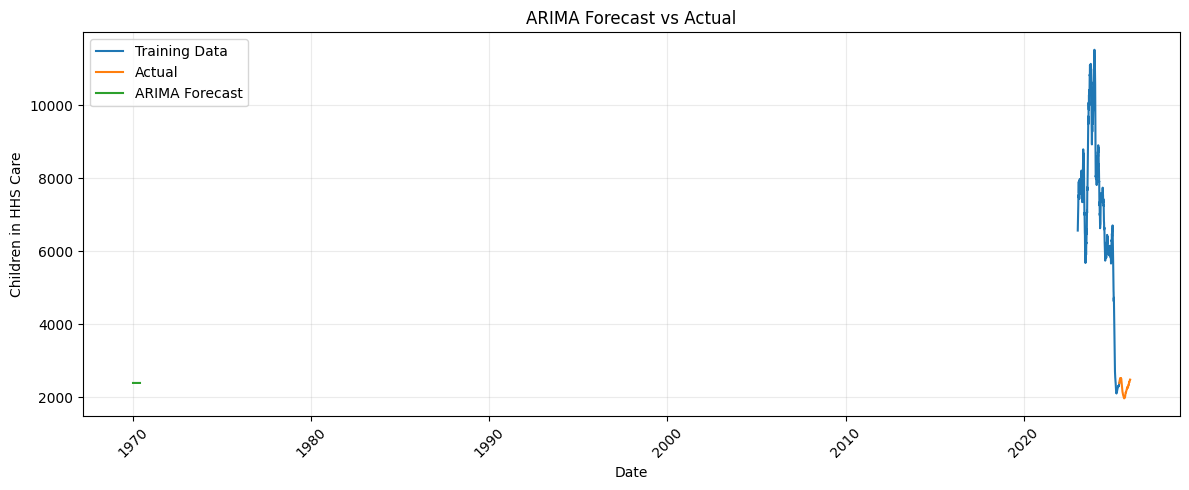

✅ ARIMA predictions saved successfully!
📁 Location: C:\Users\kapta\Downloads\UAC-Forecasting-Project-main\UAC-Forecasting-Project-main\UAC_Forecasting_Project\data\arima_predictions.csv
📊 Rows saved: 144


In [13]:
# ==========================================
# ARIMA — ROBUST VERSION
# ==========================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error


# --------------------------------------------------
# 1. Make sure train/test are valid
# --------------------------------------------------

train = pd.to_numeric(train, errors="coerce")
test = pd.to_numeric(test, errors="coerce")

train = train.replace([np.inf, -np.inf], np.nan).dropna()
test = test.replace([np.inf, -np.inf], np.nan).dropna()

print("Training observations:", len(train))
print("Testing observations:", len(test))

if len(train) < 10:
    raise ValueError(
        "Not enough training observations for ARIMA."
    )

if len(test) == 0:
    raise ValueError(
        "Test set is empty."
    )


# --------------------------------------------------
# 2. Fit ARIMA(1,1,1)
# --------------------------------------------------

print("\nFitting ARIMA(1,1,1)...")

model = ARIMA(
    train,
    order=(1, 1, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fit = model.fit()

print("✅ ARIMA model fitted successfully.")


# --------------------------------------------------
# 3. Forecast
# --------------------------------------------------

forecast = fit.forecast(
    steps=len(test)
)

forecast = pd.Series(
    np.asarray(forecast, dtype=float),
    index=test.index
)

print("\nForecast:")
print(forecast.head())

print("\nForecast NaN:", forecast.isna().sum())
print(
    "Forecast infinite:",
    np.isinf(forecast.to_numpy()).sum()
)


# --------------------------------------------------
# 4. Safety check
# --------------------------------------------------

evaluation = pd.DataFrame({
    "Actual": test.to_numpy(),
    "Forecast": forecast.to_numpy()
})

evaluation = evaluation.replace(
    [np.inf, -np.inf],
    np.nan
)

evaluation = evaluation.dropna()

print(
    "\nValid evaluation rows:",
    len(evaluation)
)

if evaluation.empty:
    print("\n❌ ARIMA produced no usable predictions.")
    print("\nModel summary:")
    print(fit.summary())

    raise RuntimeError(
        "ARIMA produced no valid predictions. "
        "The problem is with the time-series data/model, "
        "not the metric calculation."
    )


# --------------------------------------------------
# 5. Metrics
# --------------------------------------------------

actual = evaluation["Actual"]
predicted = evaluation["Forecast"]

mae = mean_absolute_error(
    actual,
    predicted
)

rmse = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

# MAPE
nonzero = actual != 0

if nonzero.any():

    mape = (
        np.mean(
            np.abs(
                (
                    actual[nonzero]
                    - predicted[nonzero]
                )
                / actual[nonzero]
            )
        )
        * 100
    )

else:

    mape = np.nan


print("\n" + "=" * 50)
print("ARIMA MODEL RESULTS")
print("=" * 50)

print(f"Model : ARIMA(1,1,1)")
print(f"MAE   : {mae:.2f}")
print(f"RMSE  : {rmse:.2f}")
print(f"MAPE  : {mape:.2f}%")

print("=" * 50)


# --------------------------------------------------
# 6. Plot
# --------------------------------------------------

plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train.values,
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    evaluation.index,
    predicted.values,
    label="ARIMA Forecast"
)

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.title(
    "ARIMA Forecast vs Actual"
)

plt.xticks(rotation=45)

plt.legend()

plt.grid(
    True,
    alpha=0.25
)

plt.tight_layout()

plt.show()


# --------------------------------------------------
# 7. Save predictions
# --------------------------------------------------

# ==========================================
# SAVE ARIMA PREDICTIONS
# ==========================================

from pathlib import Path

# Find the correct project data directory
data_candidates = [
    Path("data"),
    Path("UAC_Forecasting_Project/data")
]

data_dir = next(
    (p for p in data_candidates if p.exists()),
    None
)

if data_dir is None:
    raise FileNotFoundError(
        "Could not find the project data folder.\n"
        f"Current directory: {Path.cwd()}"
    )

# Create predictions dataframe
predictions = pd.DataFrame({
    "Date": test.index,
    "Actual": test.values,
    "ARIMA Forecast": forecast.values
})

# Save
output_path = data_dir / "arima_predictions.csv"

predictions.to_csv(
    output_path,
    index=False
)

print("✅ ARIMA predictions saved successfully!")
print("📁 Location:", output_path.resolve())
print("📊 Rows saved:", len(predictions))

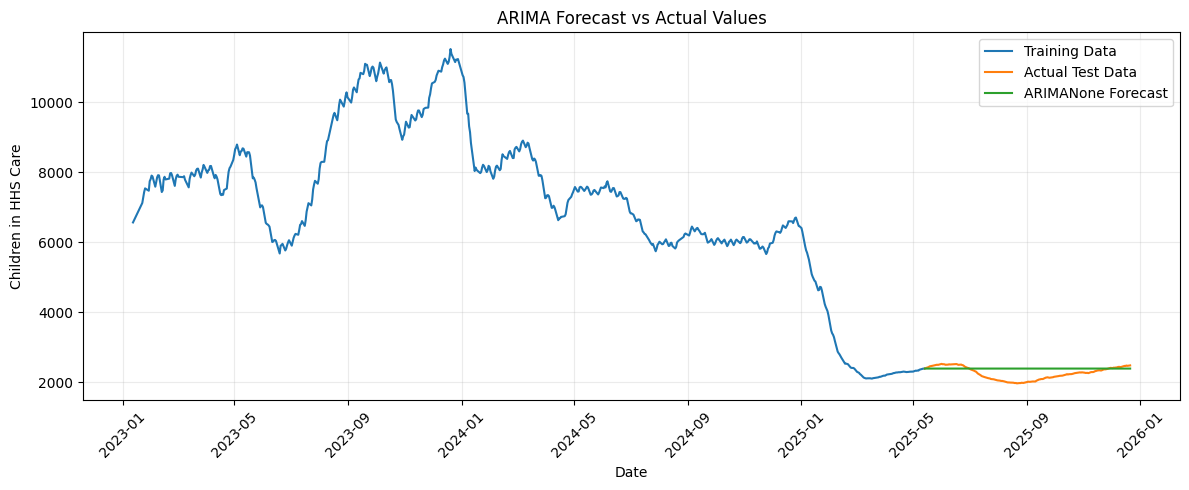

In [14]:
# 6. Plot actual vs forecast

plt.figure(figsize=(12, 5))

plt.plot(
    train.index,
    train.values,
    label="Training Data"
)

plt.plot(
    test.index,
    test.values,
    label="Actual Test Data"
)

plt.plot(
    forecast.index,
    forecast.values,
    label=f"ARIMA{selected_order} Forecast"
)

plt.xlabel("Date")
plt.ylabel("Children in HHS Care")
plt.title("ARIMA Forecast vs Actual Values")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()


In [15]:
# 7. Save predictions for later model comparison

predictions = pd.DataFrame({
    "Date": test.index,
    "Actual": test.to_numpy(),
    "ARIMA Forecast": forecast.to_numpy()
})

output_candidates = [
    Path("data/arima_predictions.csv"),
    Path("UAC_Forecasting_Project/data/arima_predictions.csv"),
]

output_path = next(
    (p for p in output_candidates if p.parent.exists()),
    output_candidates[-1]
)

output_path.parent.mkdir(parents=True, exist_ok=True)
predictions.to_csv(output_path, index=False)

# Save model metrics too
metrics = pd.DataFrame([{
    "Model": f"ARIMA{selected_order}",
    "MAE": mae,
    "RMSE": rmse,
    "MAPE": mape
}])

metrics_path = output_path.parent / "arima_metrics.csv"
metrics.to_csv(metrics_path, index=False)

print("Predictions saved to:", output_path)
print("Metrics saved to:", metrics_path)


Predictions saved to: UAC_Forecasting_Project\data\arima_predictions.csv
Metrics saved to: UAC_Forecasting_Project\data\arima_metrics.csv
